In [113]:
import scipy.stats as stats
import numpy as np
import pandas as pd

In [114]:
raux = 4
saux = 1
n = 10000

In [115]:
df = {'r': [raux] * n, 's': [saux] * n}
df = pd.DataFrame(df)

In [116]:
z1aux = []
z2aux = []
for i in df.iterrows():
    z1_mu = 1.
    z1_sc = 0.028
    s = np.sqrt(np.log(1 + (z1_sc/z1_mu)**2))
    scale = z1_mu / np.sqrt(1 + (z1_sc/z1_mu)**2)
    z1aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])
    z2_mu = 1.
    z2_sc = 0.096
    s = np.sqrt(np.log(1 + (z2_sc/z2_mu)**2))
    scale = z2_mu / np.sqrt(1 + (z2_sc/z2_mu)**2)
    z2aux.append(stats.lognorm.rvs(s=s, scale=scale, size=1)[0])

df['z1'] = z1aux
df['z2'] = z2aux
df['g'] = df['r'] / df['z1'] - df['s'] * df['z2']
df

,r,s,z1,z2,g
0,4,1,1.014544,0.962648,2.980011
1,4,1,1.021368,0.974533,2.941783
2,4,1,1.002989,1.045504,2.942576
3,4,1,0.967956,1.043699,3.088718
4,4,1,1.023349,1.043981,2.864753
...,...,...,...,...,...
9995,4,1,0.986314,0.815835,3.239668
9996,4,1,1.026013,1.163310,2.735275
9997,4,1,0.958129,1.026906,3.147899
9998,4,1,0.985700,0.813926,3.244105


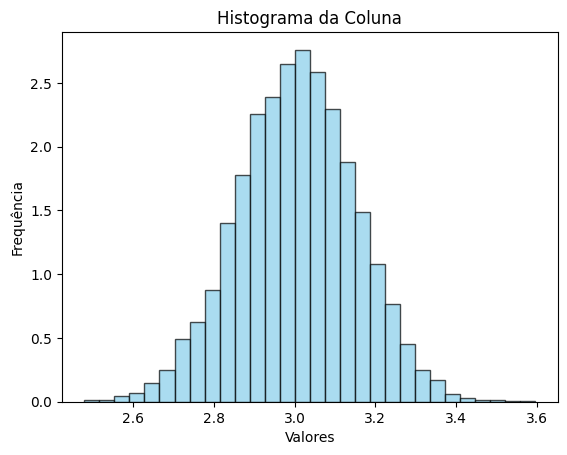

In [117]:
import matplotlib.pyplot as plt

plt.hist(df['g'],
         bins=30,                    # Número de bins
         color='skyblue',           # Cor das barras
         alpha=0.7,                 # Transparência
         edgecolor='black',         # Cor da borda
         density=True)              # Se True, mostra densidade em vez de contagem
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.title('Histograma da Coluna')
plt.show()

In [118]:
# # pip install gldpy
# from gldpy import GLD
# gld = GLD('VSL')
# data = df['g'].values
# param_ML = gld.fit_ML(data,bins_hist = 20, maxiter=1000, maxfun=1000)

(np.float64(3.005279148383016), np.float64(10.000284762121115), np.float64(0.13168901253540422), np.float64(0.1409163703761481))


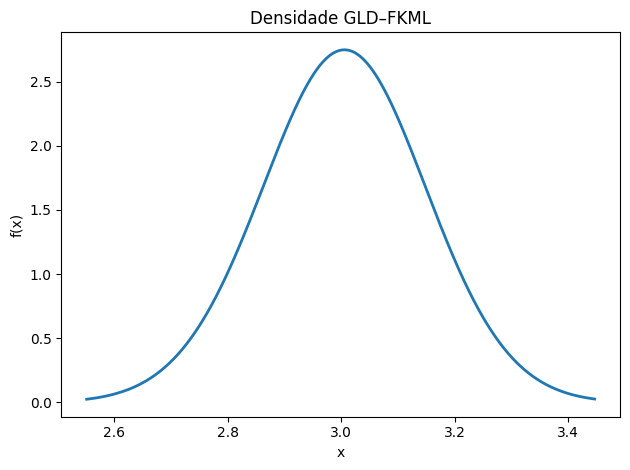

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ================= FKML: núcleo matemático =================
def _phi(u, lam):
    # Trata lam -> 0 por continuidade: (u^lam - 1)/lam -> ln(u)
    return np.where(np.isclose(lam, 0.0), np.log(u), (u**lam - 1.0)/lam)

def gld_fkml_quantile(u, l1, l2, l3, l4):
    u = np.clip(u, 1e-12, 1-1e-12)
    return l1 + ( _phi(u, l3) - _phi(1-u, l4) ) / l2

def gld_fkml_qprime(u, l2, l3, l4):
    # Q'(u) = (u^(l3-1) + (1-u)^(l4-1)) / l2, com limites log quando lam≈0
    u = np.clip(u, 1e-12, 1-1e-12)
    term1 = np.where(np.isclose(l3, 0.0), 1.0/u, u**(l3 - 1.0))
    term2 = np.where(np.isclose(l4, 0.0), 1.0/(1.0 - u), (1.0 - u)**(l4 - 1.0))
    return (term1 + term2) / l2

# Newton estável para resolver x = Q(u)
def _solve_u_for_x(x, l1, l2, l3, l4, maxit=60, tol=1e-10):
    x = np.atleast_1d(x).astype(float)
    # chute inicial por ranking -> (0,1)
    ranks = (np.argsort(np.argsort(x)) + 0.5) / (len(x) + 1.0)
    u = np.clip(ranks, 1e-4, 1-1e-4)
    for _ in range(maxit):
        q  = gld_fkml_quantile(u, l1, l2, l3, l4)
        qp = gld_fkml_qprime(u, l2, l3, l4)
        step = (q - x)/np.maximum(qp, 1e-16)
        u_new = np.clip(u - step, 1e-8, 1-1e-8)
        if np.max(np.abs(u_new - u)) < tol:
            u = u_new
            break
        u = u_new
    return u

def gld_fkml_pdf(x, l1, l2, l3, l4):
    if l2 <= 0:
        return np.full_like(np.atleast_1d(x), 0.0, dtype=float)
    u  = _solve_u_for_x(x, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)
    return 1.0/np.maximum(qp, 1e-300)

# ================= MLE com bounds e padronização =================
def _mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med))

def fit_gld_fkml_mle(data, x0=None, bounds=None):
    data = np.asarray(data, dtype=float)
    # Padroniza para estabilizar a busca
    m, s = np.median(data), (1.4826*_mad(data) or np.std(data, ddof=1) or 1.0)
    z = (data - m)/s

    # inicialização
    if x0 is None:
        x0 = np.array([0.0, 1.0, 0.1, 0.1])  # l1≈0, l2≈1, leve assimetria

    # bounds: l2>0; restringe forma para evitar explosões numéricas
    if bounds is None:
        bounds = [(-np.inf, np.inf), (1e-4, np.inf), (-3.0, 3.0), (-3.0, 3.0)]

    def nll(params):
        l1, l2, l3, l4 = params
        if not np.isfinite(l1 + l2 + l3 + l4) or l2 <= 0:
            return np.inf
        f = gld_fkml_pdf(z, l1, l2, l3, l4)
        if np.any(f <= 0) or np.any(~np.isfinite(f)):
            return np.inf
        return -np.sum(np.log(f))

    res = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)

    # desfaz padronização: Qx(u) = m + s * Qz(u)  => l1x = m + s*l1z ; l2x = l2z / s
    l1z, l2z, l3, l4 = res.x
    l1x = m + s*l1z
    l2x = l2z / s
    return (l1x, l2x, l3, l4), res

# ================= Plot APENAS da GLD =================
def plot_gld_only(lambdas, n_points=2000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0/qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    plt.figure()
    plt.plot(x, f, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Densidade GLD–FKML")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

# ========================= EXEMPLO =========================
lambdas, _ = fit_gld_fkml_mle(df['g'].values)     # data = seu array 1D
print(lambdas)
plot_gld_only(lambdas, quantile_trim=1e-3, qp_min=1e-7, ylim=None)


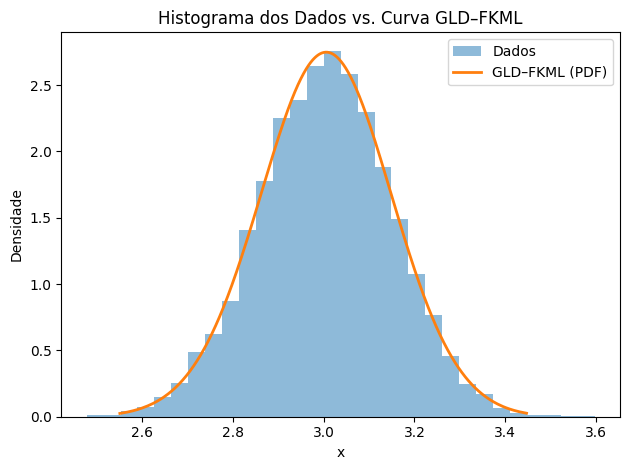

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Núcleo FKML ----------
def _phi(u, lam):
    # Trata lam -> 0 por continuidade: (u^lam - 1)/lam -> ln(u)
    return np.where(np.isclose(lam, 0.0), np.log(u), (u**lam - 1.0)/lam)

def gld_fkml_quantile(u, l1, l2, l3, l4):
    u = np.clip(u, 1e-12, 1-1e-12)
    return l1 + (_phi(u, l3) - _phi(1 - u, l4)) / l2

def gld_fkml_qprime(u, l2, l3, l4):
    u = np.clip(u, 1e-12, 1-1e-12)
    term1 = np.where(np.isclose(l3, 0.0), 1.0/u, u**(l3 - 1.0))
    term2 = np.where(np.isclose(l4, 0.0), 1.0/(1.0 - u), (1.0 - u)**(l4 - 1.0))
    return (term1 + term2) / l2

# ---------- Plot: histograma (dados) + curva GLD (PDF) ----------
def plot_gld_vs_data(data, lambdas, bins=30, n_points=2000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    data = np.asarray(data, dtype=float)
    l1, l2, l3, l4 = lambdas

    # Histograma dos dados (densidade)
    plt.figure()
    plt.hist(data, bins=bins, density=True, alpha=0.5, label="Dados")

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    plt.plot(x, f, linewidth=2, label="GLD–FKML (PDF)")
    plt.xlabel("x")
    plt.ylabel("Densidade")
    plt.title("Histograma dos Dados vs. Curva GLD–FKML")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------- Exemplo de uso -----------------
data = df['g'].values              # seu dataset 1D
plot_gld_vs_data(data, lambdas, bins=30, quantile_trim=1e-3, qp_min=1e-7)
